In [499]:
import numpy as np
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin-1')

In [501]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [502]:
df.shape

(5572, 5)

In [503]:
# Data_cleaning
# EDA
# Text_Preprocessing
# Evalution
# Improvents
# Website
# Deploy

## 1.Data Cleaning

In [505]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [506]:
# drop last 3 columns :
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace = True)

In [507]:
df.sample(5)

,v1,v2
1974,ham,Thats cool. Where should i cum? On you or in y...
4528,ham,"Hiya, probably coming home * weekend after next"
2138,ham,K still are you loving me.
1545,ham,"Good afternoon, my love ! Any job prospects ? ..."
4471,spam,3. You have received your mobile content. Enjoy


In [508]:
# renaming column
df.rename(columns={'v1':'target','v2':'text'},inplace= True)

In [509]:
## lable encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [510]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [511]:
# duplicate values
df.duplicated().sum()

403

In [512]:
# remove duplicates
df=df.drop_duplicates(keep='first')
df.shape

(5169, 2)

# EDA

In [514]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

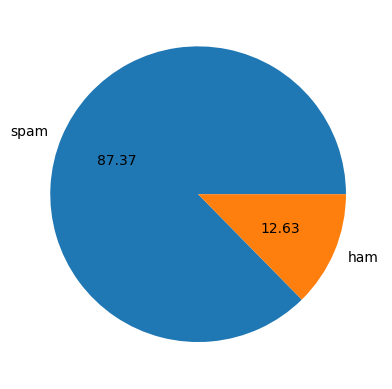

In [515]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['spam','ham'],autopct='%0.2f')
plt.show()

In [516]:
# Data is imbalanced

In [517]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tuhin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [518]:
# Counting characters of each comments
df['num_characters']=df['text'].apply(len)

In [519]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [520]:
# fetching number of words

from nltk.tokenize import word_tokenize
def toke(text):
    tokens=word_tokenize(text)
    return len(tokens)
df['num_words']=df['text'].apply(toke)    

In [521]:
# fetching sentences from text

from nltk.tokenize import sent_tokenize
def sent_toke(text):
    token=sent_tokenize(text)
    return len(token)
df['num_sentences']=df['text'].apply(sent_toke)

In [522]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [523]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [524]:
# describe ham massages
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [525]:
# dESCRIBE SPAM
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [526]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

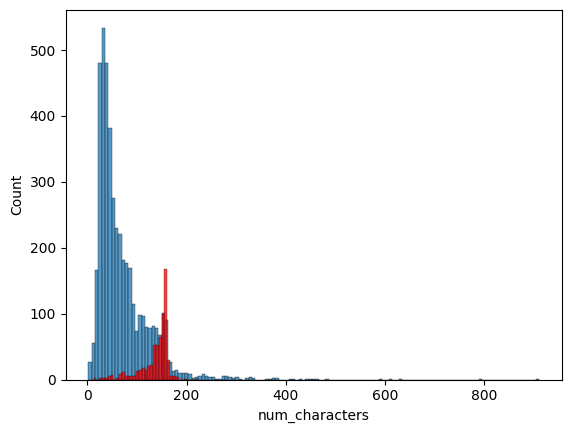

In [527]:
# spam vs ham count on 'num_characters' :
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')           

<Axes: xlabel='num_words', ylabel='Count'>

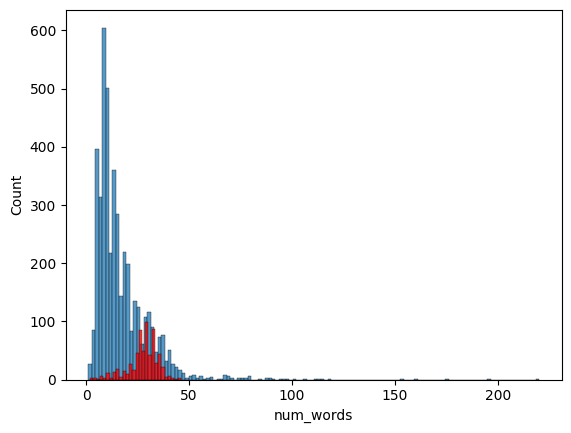

In [528]:
# spam vs ham count on 'num_characters' :
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')           

In [529]:
## Most number of spam massages has more charecter or words

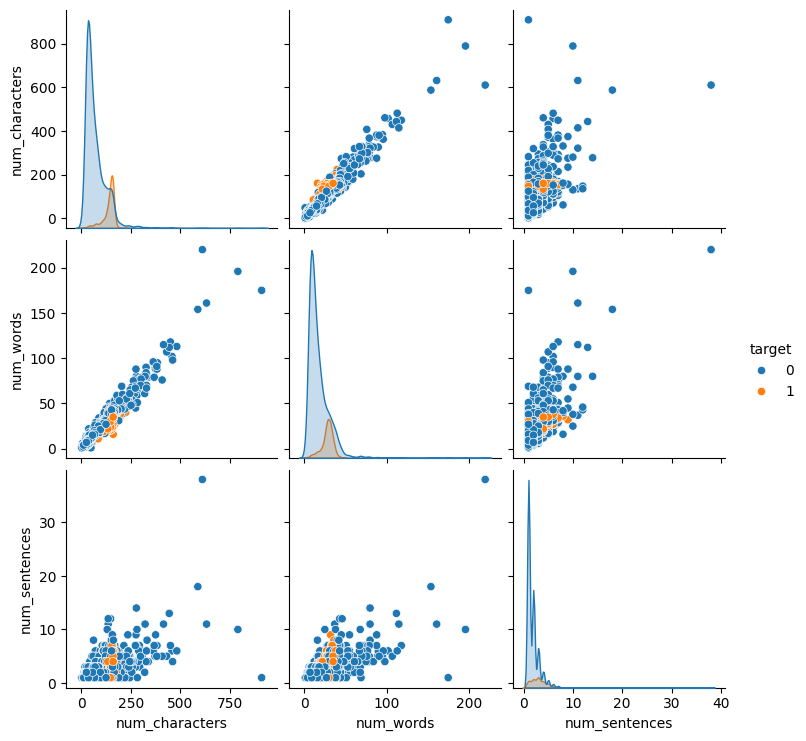

In [530]:
sns.pairplot(df,hue='target')

<Axes: >

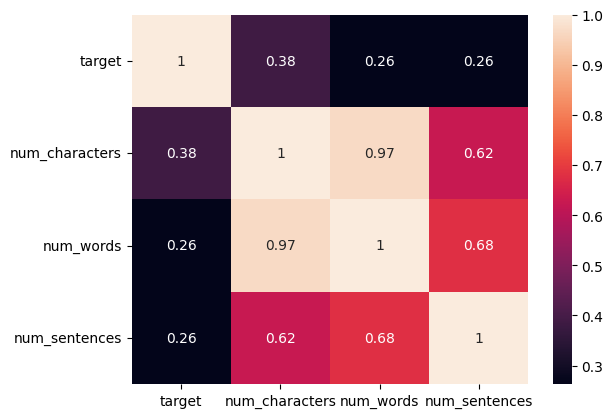

In [531]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Text preprocessing
 - Expand Contractions
 - Lower Case
 - Tokenization
 - Removing Special charecters
 - Removing stopwods
 - stemming

In [ ]:
from nltk.tokenize import word_tokenize
import re
from nltk.corpus import stopwords
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [538]:
ps = PorterStemmer()
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text= y[:]
    y.clear()
    for j in text:
        if j not in stopwords.words('english') and j not in string.punctuation:
            y.append(j)
    text=y[:]
    y.clear()
    for k in text:
        y.append(ps.stem(k))
    return y

In [539]:
transform_text('''I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
''')

['gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today']

In [540]:
df['transformed_text']=df['text'].apply(transform_text)

In [541]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"


### Word Cloud

In [543]:
from wordcloud import WordCloud

In [549]:
df['transformed_text'] = df['transformed_text'].apply(lambda x: " ".join(x))

In [558]:
# For Spam
wc = WordCloud(width=900,height=700,min_font_size=10,background_color='black')
spam_wc=wc.generate(df[df['target']== 1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

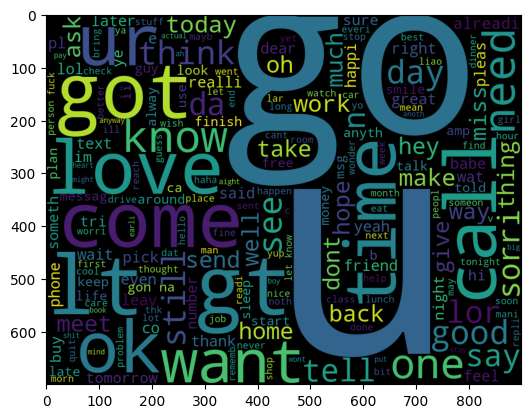

In [562]:
# For Ham
wc = WordCloud(width=900,height=700,min_font_size=10,background_color='black')
spam_wc=wc.generate(df[df['target']== 0]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

## Spam Corpus

In [566]:
## Collecting spam words
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [570]:
len(spam_corpus)

9939

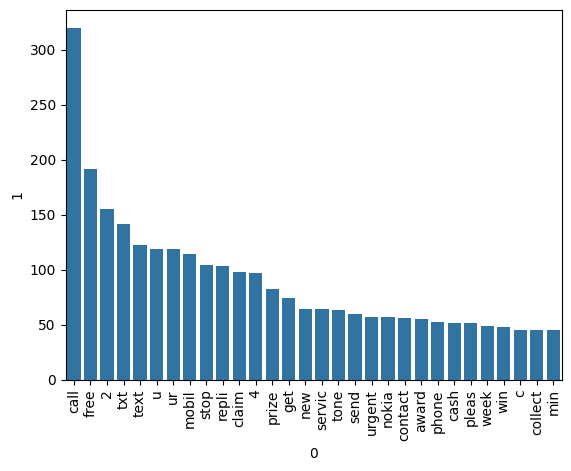

In [588]:
from collections import Counter
import matplotlib.pyplot as plt
df_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=df_words[0], y=df_words[1])
plt.xticks(rotation='vertical')
plt.show()

## Ham corpus

In [598]:
## Collecting ham words
ham_corpus=[]
for sent in df[df['target']==0]['transformed_text'].tolist():
    for word in sent.split():
        ham_corpus.append(word)

In [602]:
len(ham_corpus)

35404

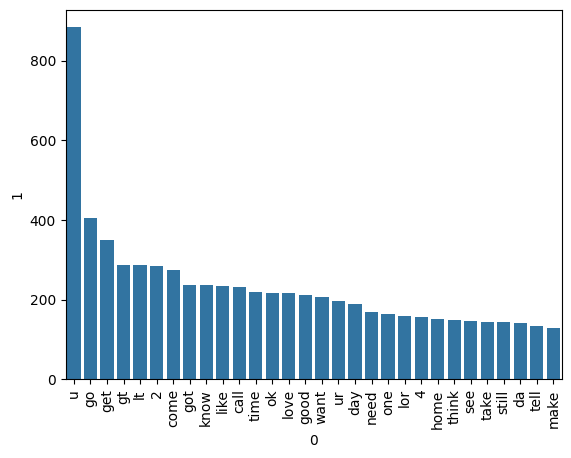

In [604]:
df_words = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=df_words[0], y=df_words[1])
plt.xticks(rotation='vertical')
plt.show()

# Building model

In [844]:
## vecterization of text
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [846]:
X= tfidf.fit_transform(df['transformed_text']).toarray()
Y= df['target'].values

In [848]:
X.shape

(5169, 3000)

In [850]:
Y.shape

(5169,)

In [852]:
# Model selection
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [854]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [856]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

### GaussianNB

In [859]:
gnb.fit(X_train,Y_train)
Y_pred = gnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(precision_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))

0.8694390715667312
0.5068493150684932
[[788 108]
 [ 27 111]]


### MultinomialNB(best-fited)

In [878]:
mnb.fit(X_train,Y_train)
Y_pred = mnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(precision_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))

0.9709864603481625
1.0
[[896   0]
 [ 30 108]]


### BernoulliNB

In [881]:
bnb.fit(X_train,Y_train)
Y_pred = bnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(precision_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))

0.9835589941972921
0.991869918699187
[[895   1]
 [ 16 122]]


In [884]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))

In [ ]:
import pickle

vectorizer = pickle.load(open('vectorizer.pkl','rb'))